In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

## Solution
### Part 1

In [2]:
%%duckdb

CREATE OR REPLACE MACRO get_trips() AS TABLE
SELECT 
  *, 
  date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
);

SELECT *
FROM get_trips()
LIMIT 3;

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


In [3]:
%%duckdb

CREATE OR REPLACE MACRO get_trip_features() AS TABLE
SELECT
    duration_min,

    start_at,
    stop_at,

    "start station id",
    "start station name",
    "start station latitude",
    "start station longitude",

    "end station id",
    "end station name",
    "end station latitude",
    "end station longitude",

    EXTRACT('hour' FROM start_at) AS hour_of_day,

    EXTRACT('dow' FROM start_at) AS day_of_week,

    CASE 
        WHEN EXTRACT('dow' FROM start_at) IN (0, 6) THEN 1
        ELSE 0
    END AS is_weekend,

    6371 * 2 * asin(
        sqrt(
            power(sin(radians(("end station latitude" - "start station latitude") / 2)), 2)
            +
            cos(radians("start station latitude"))
            * cos(radians("end station latitude"))
            * power(sin(radians(("end station longitude" - "start station longitude") / 2)), 2)
        )
    ) AS distance_km,

    (
        abs("end station latitude" - "start station latitude") * 111
        +
        abs("end station longitude" - "start station longitude") * 85
    ) AS manhattan_distance_km

FROM get_trips()

WHERE
    "start station latitude" IS NOT NULL
    AND "start station longitude" IS NOT NULL
    AND "end station latitude" IS NOT NULL
    AND "end station longitude" IS NOT NULL;

,Count


In [4]:
%%duckdb

SELECT
    duration_min,
    hour_of_day,
    day_of_week,
    is_weekend,
    distance_km,
    manhattan_distance_km
FROM get_trip_features()
LIMIT 10;

,duration_min,hour_of_day,day_of_week,is_weekend,distance_km,manhattan_distance_km
0,23,0,4,0,3.615820,4.983529
1,6,0,4,0,0.560745,0.793378
2,6,0,4,0,0.918719,1.102690
3,3,0,4,0,0.602053,0.694541
4,16,0,4,0,2.122555,2.361169
5,8,0,4,0,1.657115,1.806300
6,2,0,4,0,0.390487,0.481820
7,20,0,4,0,2.592390,2.739514
8,14,0,4,0,0.812327,1.141747
9,10,0,4,0,1.121495,1.195399


In [5]:
%%duckdb

CREATE OR REPLACE MACRO get_model_data() AS TABLE
SELECT
    row_number() OVER () AS row_id,
    *
FROM get_trip_features()
WHERE
    duration_min > 0
    AND duration_min < 120
    AND distance_km > 0
    AND distance_km < 10
    AND manhattan_distance_km > 0
    AND manhattan_distance_km < 20;

,Count


In [6]:
%%duckdb

SELECT
    count(*) AS n,
    min(duration_min) AS min_duration,
    avg(duration_min) AS avg_duration,
    max(duration_min) AS max_duration,
    min(distance_km) AS min_distance,
    avg(distance_km) AS avg_distance,
    max(distance_km) AS max_distance
FROM get_model_data();

,n,min_duration,avg_duration,max_duration,min_distance,avg_distance,max_distance
0,23205250,1,13.370561,119,0.023117,1.803297,9.999793


## part2

In [7]:
%%duckdb

CREATE OR REPLACE MACRO get_train_data() AS TABLE
SELECT *
FROM get_model_data()
WHERE row_id % 5 != 0;

CREATE OR REPLACE MACRO get_test_data() AS TABLE
SELECT *
FROM get_model_data()
WHERE row_id % 5 = 0;

,Count


In [8]:
%%duckdb

SELECT 'train' AS split, count(*) AS row_count
FROM get_train_data()

UNION ALL

SELECT 'test' AS split, count(*) AS row_count
FROM get_test_data();

,split,row_count
0,train,18564200
1,test,4641050


In [9]:
%%duckdb -t pl -o train_df

SELECT
    duration_min,
    distance_km,
    manhattan_distance_km,
    hour_of_day,
    day_of_week,
    is_weekend
FROM get_train_data()
WHERE row_id % 40 = 1;

duration_min,distance_km,manhattan_distance_km,hour_of_day,day_of_week,is_weekend
i64,f64,f64,i64,i64,i32
23,3.61582,4.983529,0,4,0
5,0.591369,0.81205,0,4,0
16,2.149009,2.337742,0,4,0
12,1.705621,1.797268,1,4,0
6,0.894073,1.22116,1,4,0
…,…,…,…,…,…
9,0.926909,1.144853,23,6,1
17,1.21358,1.633548,23,6,1
7,1.273715,1.430019,23,6,1


In [10]:
%%duckdb -t pl -o test_df

SELECT
    duration_min,
    distance_km,
    manhattan_distance_km,
    hour_of_day,
    day_of_week,
    is_weekend
FROM get_test_data()
WHERE row_id % 250 = 0;

duration_min,distance_km,manhattan_distance_km,hour_of_day,day_of_week,is_weekend
i64,f64,f64,i64,i64,i32
18,2.75591,3.761613,1,4,0
16,2.841962,4.030512,4,4,0
13,2.354528,3.071232,9,4,0
13,1.165226,1.432916,10,4,0
19,1.66739,2.351965,11,4,0
…,…,…,…,…,…
6,1.037207,1.140861,21,6,1
25,4.447525,5.915996,21,6,1
6,0.774124,1.081548,22,6,1


In [11]:
import numpy as np
import polars as pl


def make_features(df):
    distance = df["distance_km"].to_numpy()
    manhattan_distance = df["manhattan_distance_km"].to_numpy()
    hour = df["hour_of_day"].to_numpy()
    weekend = df["is_weekend"].to_numpy()
    day = df["day_of_week"].to_numpy()

    n = len(df)

    # bias / intercept
    bias = np.ones(n)

    # day_of_week one-hot
    # 0 = Sunday baseline olarak dışarıda kalıyor
    monday = (day == 1).astype(float)
    tuesday = (day == 2).astype(float)
    wednesday = (day == 3).astype(float)
    thursday = (day == 4).astype(float)
    friday = (day == 5).astype(float)
    saturday = (day == 6).astype(float)

    X = np.column_stack([
        bias,
        distance,
        manhattan_distance,
        hour,
        weekend,
        monday,
        tuesday,
        wednesday,
        thursday,
        friday,
        saturday,
    ])

    feature_names = [
        "bias",
        "distance_km",
        "manhattan_distance_km",
        "hour_of_day",
        "is_weekend",
        "monday",
        "tuesday",
        "wednesday",
        "thursday",
        "friday",
        "saturday",
    ]

    return X, feature_names


X_train, feature_names = make_features(train_df)
y_train = train_df["duration_min"].to_numpy()

X_test, _ = make_features(test_df)
y_test = test_df["duration_min"].to_numpy()


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (580132, 11)
y_train shape: (580132,)
X_test shape: (92821, 11)
y_test shape: (92821,)


In [12]:
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]


weights, residuals, rank, s = np.linalg.lstsq(X_train, y_train, rcond=None)


y_pred = X_test @ weights

print("y_pred shape:", y_pred.shape)

assert y_pred.shape[0] == y_test.shape[0]


# hatalar
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("MAE:", mae)
print("RMSE:", rmse)

y_pred shape: (92821,)
MAE: 4.358033219760324
RMSE: 7.855402433238837


In [13]:
# katsayilar
coef_df = pl.DataFrame({
    "feature": feature_names,
    "weight": weights
})

coef_df

feature,weight
str,f64
"""bias""",2.348632
"""distance_km""",5.141177
"""manhattan_distance_km""",0.058225
"""hour_of_day""",0.077187
"""is_weekend""",2.289334
…,…
"""tuesday""",-0.18754
"""wednesday""",-0.093177
"""thursday""",-0.091303


In [14]:
%%duckdb -t pl -o fictional_trips

WITH stations AS (
    SELECT DISTINCT
        "start station id" AS station_id,
        "start station name" AS station_name,
        "start station latitude" AS latitude,
        "start station longitude" AS longitude
    FROM get_trips()
    WHERE
        "start station latitude" BETWEEN 40.65 AND 40.85
        AND "start station longitude" BETWEEN -74.05 AND -73.85
),

random_pairs AS (
    SELECT
        row_number() OVER () AS trip_id,

        s1.station_id AS start_station_id,
        s1.station_name AS start_station_name,
        s1.latitude AS start_latitude,
        s1.longitude AS start_longitude,

        s2.station_id AS end_station_id,
        s2.station_name AS end_station_name,
        s2.latitude AS end_latitude,
        s2.longitude AS end_longitude

    FROM stations s1
    CROSS JOIN stations s2
    WHERE s1.station_id != s2.station_id
    ORDER BY random()
    LIMIT 10
)

SELECT
    trip_id,

    start_station_id,
    start_station_name,
    start_latitude,
    start_longitude,

    end_station_id,
    end_station_name,
    end_latitude,
    end_longitude,

    12 AS hour_of_day,
    3 AS day_of_week,
    0 AS is_weekend,

    6371 * 2 * asin(
        sqrt(
            power(sin(radians((end_latitude - start_latitude) / 2)), 2)
            +
            cos(radians(start_latitude))
            * cos(radians(end_latitude))
            * power(sin(radians((end_longitude - start_longitude) / 2)), 2)
        )
    ) AS distance_km,

    (
        abs(end_latitude - start_latitude) * 111
        +
        abs(end_longitude - start_longitude) * 85
    ) AS manhattan_distance_km

FROM random_pairs

WHERE
    6371 * 2 * asin(
        sqrt(
            power(sin(radians((end_latitude - start_latitude) / 2)), 2)
            +
            cos(radians(start_latitude))
            * cos(radians(end_latitude))
            * power(sin(radians((end_longitude - start_longitude) / 2)), 2)
        )
    ) < 5;

trip_id,start_station_id,start_station_name,start_latitude,start_longitude,end_station_id,end_station_name,end_latitude,end_longitude,hour_of_day,day_of_week,is_weekend,distance_km,manhattan_distance_km
i64,i64,str,f64,f64,i64,str,f64,f64,i32,i32,i32,f64,f64
43850,3413,"""Wyckoff St & 3 Ave""",40.682755,-73.982586,342,"""Columbia St & Rivington St""",40.7174,-73.980166,12,3,0,3.857727,4.051276
263342,3264,"""E 61 St & Park Ave""",40.76421,-73.969105,225,"""W 14 St & The High Line""",40.741951,-74.00803,12,3,0,4.108119,5.779386
37558,3295,"""Central Park W & W 96 St""",40.79127,-73.964839,529,"""W 42 St & 8 Ave""",40.75757,-73.990985,12,3,0,4.346199,5.963127
431509,137,"""E 56 St & Madison Ave""",40.761628,-73.972924,3291,"""Riverside Dr & W 91 St""",40.793372,-73.976851,12,3,0,3.545205,3.85737
366158,3428,"""8 Ave & W 16 St""",40.740983,-74.001702,3109,"""Banker St & Meserole Ave""",40.72606,-73.95621,12,3,0,4.176836,5.523273
105447,3224,"""W 13 St & Hudson St""",40.739974,-74.005139,330,"""Reade St & Broadway""",40.714505,-74.005628,12,3,0,2.832327,2.868641
353731,540,"""Lexington Ave & E 26 St""",40.741473,-73.983209,521,"""8 Ave & W 31 St""",40.750967,-73.994442,12,3,0,1.417753,2.008676


In [15]:
fictional_trips

trip_id,start_station_id,start_station_name,start_latitude,start_longitude,end_station_id,end_station_name,end_latitude,end_longitude,hour_of_day,day_of_week,is_weekend,distance_km,manhattan_distance_km
i64,i64,str,f64,f64,i64,str,f64,f64,i32,i32,i32,f64,f64
43850,3413,"""Wyckoff St & 3 Ave""",40.682755,-73.982586,342,"""Columbia St & Rivington St""",40.7174,-73.980166,12,3,0,3.857727,4.051276
263342,3264,"""E 61 St & Park Ave""",40.76421,-73.969105,225,"""W 14 St & The High Line""",40.741951,-74.00803,12,3,0,4.108119,5.779386
37558,3295,"""Central Park W & W 96 St""",40.79127,-73.964839,529,"""W 42 St & 8 Ave""",40.75757,-73.990985,12,3,0,4.346199,5.963127
431509,137,"""E 56 St & Madison Ave""",40.761628,-73.972924,3291,"""Riverside Dr & W 91 St""",40.793372,-73.976851,12,3,0,3.545205,3.85737
366158,3428,"""8 Ave & W 16 St""",40.740983,-74.001702,3109,"""Banker St & Meserole Ave""",40.72606,-73.95621,12,3,0,4.176836,5.523273
105447,3224,"""W 13 St & Hudson St""",40.739974,-74.005139,330,"""Reade St & Broadway""",40.714505,-74.005628,12,3,0,2.832327,2.868641
353731,540,"""Lexington Ave & E 26 St""",40.741473,-73.983209,521,"""8 Ave & W 31 St""",40.750967,-73.994442,12,3,0,1.417753,2.008676


In [16]:
X_fictional, _ = make_features(fictional_trips)

fictional_pred = X_fictional @ weights

fictional_trips = fictional_trips.with_columns(
    pl.Series("predicted_duration_min", fictional_pred)
)

fictional_trips.select([
    "trip_id",
    "start_station_name",
    "end_station_name",
    "distance_km",
    "manhattan_distance_km",
    "predicted_duration_min",
])

trip_id,start_station_name,end_station_name,distance_km,manhattan_distance_km,predicted_duration_min
i64,str,str,f64,f64,f64
43850,"""Wyckoff St & 3 Ave""","""Columbia St & Rivington St""",3.857727,4.051276,23.25085
263342,"""E 61 St & Park Ave""","""W 14 St & The High Line""",4.108119,5.779386,24.638777
37558,"""Central Park W & W 96 St""","""W 42 St & 8 Ave""",4.346199,5.963127,25.873488
431509,"""E 56 St & Madison Ave""","""Riverside Dr & W 91 St""",3.545205,3.85737,21.632826
366158,"""8 Ave & W 16 St""","""Banker St & Meserole Ave""",4.176836,5.523273,24.97715
105447,"""W 13 St & Hudson St""","""Reade St & Broadway""",2.832327,2.868641,17.910226
353731,"""Lexington Ave & E 26 St""","""8 Ave & W 31 St""",1.417753,2.008676,10.587576


In [17]:
# https://deckgl.readthedocs.io/en/latest/jupyter.html

In [42]:
import pydeck as pdk
import json

map_df = fictional_trips.select([
    "trip_id",
    "start_station_name",
    "end_station_name",
    "start_latitude",
    "start_longitude",
    "end_latitude",
    "end_longitude",
    "predicted_duration_min",
    "distance_km",
]).to_pandas()

map_df["predicted_duration_min"] = map_df["predicted_duration_min"].round(2)
map_df["distance_km"] = map_df["distance_km"].round(2)

# hepsi kırmizi renklendirme yaptım !!!

avg_duration = map_df["predicted_duration_min"].mean()

map_df["color"] = map_df["predicted_duration_min"].apply(
    lambda x: [255, 80, 80] if x >= avg_duration else [80, 200, 80]
)

map_data = json.loads(map_df.to_json(orient="records"))

layer = pdk.Layer(
    "LineLayer",
    data=map_data,
    get_source_position="[start_longitude, start_latitude]",
    get_target_position="[end_longitude, end_latitude]",
    #renklendirme
    get_color="color",
    get_width=5,
    pickable=True,
)

view_state = pdk.ViewState(
    latitude=map_df["start_latitude"].mean(),
    longitude=map_df["start_longitude"].mean(),
    zoom=12,
)

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
)

deck

{
  "initialViewState": {
    "latitude": 40.746041767532105,
    "longitude": -73.9827861632963,
    "zoom": 12
  },
  "layers": [
    {
      "@@type": "LineLayer",
      "data": [
        {
          "color": [
            255,
            80,
            80
          ],
          "distance_km": 3.86,
          "end_latitude": 40.71739973,
          "end_longitude": -73.98016555,
          "end_station_name": "Columbia St & Rivington St",
          "predicted_duration_min": 23.25,
          "start_latitude": 40.6827549,
          "start_longitude": -73.98258555,
          "start_station_name": "Wyckoff St & 3 Ave",
          "trip_id": 43850
        },
        {
          "color": [
            255,
            80,
            80
          ],
          "distance_km": 4.11,
          "end_latitude": 40.74195138,
          "end_longitude": -74.00803013,
          "end_station_name": "W 14 St & The High Line",
          "predicted_duration_min": 24.64,
          "start_latitude": 40.7642100717,
          "start_longitude": -73.969104588,
          "start_station_name": "E 61 St & Park Ave",
          "trip_id": 263342
        },
        {
          "color": [
            255,
            80,
            80
          ],
          "distance_km": 4.35,
          "end_latitude": 40.7575699,
          "end_longitude": -73.99098507,
          "end_station_name": "W 42 St & 8 Ave",
          "predicted_duration_min": 25.87,
          "start_latitude": 40.79127,
          "start_longitude": -73.964839,
          "start_station_name": "Central Park W & W 96 St",
          "trip_id": 37558
        },
        {
          "color": [
            255,
            80,
            80
          ],
          "distance_km": 3.55,
          "end_latitude": 40.7933718,
          "end_longitude": -73.97685115,
          "end_station_name": "Riverside Dr & W 91 St",
          "predicted_duration_min": 21.63,
          "start_latitude": 40.761628,
          "start_longitude": -73.972924,
          "start_station_name": "E 56 St & Madison Ave",
          "trip_id": 431509
        },
        {
          "color": [
            255,
            80,
            80
          ],
          "distance_km": 4.18,
          "end_latitude": 40.72606,
          "end_longitude": -73.95621,
          "end_station_name": "Banker St & Meserole Ave",
          "predicted_duration_min": 24.98,
          "start_latitude": 40.740983,
          "start_longitude": -74.001702,
          "start_station_name": "8 Ave & W 16 St",
          "trip_id": 366158
        },
        {
          "color": [
            80,
            200,
            80
          ],
          "distance_km": 2.83,
          "end_latitude": 40.71450451,
          "end_longitude": -74.00562789,
          "end_station_name": "Reade St & Broadway",
          "predicted_duration_min": 17.91,
          "start_latitude": 40.739973541,
          "start_longitude": -74.005138725,
          "start_station_name": "W 13 St & Hudson St",
          "trip_id": 105447
        },
        {
          "color": [
            80,
            200,
            80
          ],
          "distance_km": 1.42,
          "end_latitude": 40.75096735,
          "end_longitude": -73.99444208,
          "end_station_name": "8 Ave & W 31 St",
          "predicted_duration_min": 10.59,
          "start_latitude": 40.74147286,
          "start_longitude": -73.98320928,
          "start_station_name": "Lexington Ave & E 26 St",
          "trip_id": 353731
        }
      ],
      "getColor": "@@=color",
      "getSourcePosition": "@@=[start_longitude, start_latitude]",
      "getTargetPosition": "@@=[end_longitude, end_latitude]",
      "getWidth": 5,
      "id": "b8ef79c0-2362-4a7a-9fe9-97901f9b2987",
      "pickable": true
    }
  ],
  "mapProvider": "carto",
  "mapStyle": "https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
  "views": [
    {
      "@@type": "MapView",
      "controller": true
    }
  ]
}

In [19]:
# yesil = ortalamadan hızlı/kısa tahmin
## kirmizi = ortalamadan yavaş/uzun tahmin

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [20]:
# Sürekli değişkende tek noktanın olasılığı sıfır

In [21]:
%%duckdb

CREATE OR REPLACE MACRO get_gender_speed_data() AS TABLE
SELECT
    row_number() OVER () AS row_id,
    gender,
    duration_min,
    distance_km,
    distance_km / (duration_min / 60.0) AS speed_kmh
FROM (
    SELECT
        gender,
        date_diff('minute', start_at, stop_at) AS duration_min,

        6371 * 2 * asin(
            sqrt(
                power(sin(radians(("end station latitude" - "start station latitude") / 2)), 2)
                +
                cos(radians("start station latitude"))
                * cos(radians("end station latitude"))
                * power(sin(radians(("end station longitude" - "start station longitude") / 2)), 2)
            )
        ) AS distance_km

    FROM get_trips()

    WHERE
        gender IN (1, 2)
        AND "start station latitude" IS NOT NULL
        AND "start station longitude" IS NOT NULL
        AND "end station latitude" IS NOT NULL
        AND "end station longitude" IS NOT NULL
)
WHERE
    duration_min > 0
    AND duration_min < 120
    AND distance_km > 0
    AND distance_km < 10
    AND distance_km / (duration_min / 60.0) > 0
    AND distance_km / (duration_min / 60.0) < 40;

,Count


In [22]:
%%duckdb

SELECT *
FROM get_gender_speed_data()
LIMIT 10;

,row_id,gender,duration_min,distance_km,speed_kmh
0,1,2,23,3.615820,9.432573
1,2,1,6,0.560745,5.607454
2,3,1,6,0.918719,9.187193
3,4,1,3,0.602053,12.041055
4,5,1,16,2.122555,7.959583
5,6,2,8,1.657115,12.428365
6,7,1,2,0.390487,11.714623
7,8,2,20,2.592390,7.777169
8,9,1,14,0.812327,3.481403
9,10,1,10,1.121495,6.728969


In [23]:
%%duckdb

SELECT
    gender,
    count(*) AS n,
    avg(speed_kmh) AS avg_speed,
    approx_quantile(speed_kmh, 0.5) AS median_speed,
    approx_quantile(speed_kmh, 0.95) AS p95_speed
FROM get_gender_speed_data()
GROUP BY gender
ORDER BY gender;

,gender,n,avg_speed,median_speed,p95_speed
0,1,15598385,9.569827,9.505786,14.461355
1,2,4906362,8.588793,8.522948,12.998498


In [24]:
## modeli seçmeden önce bir görsel alalım

In [26]:
%%duckdb -t pl -o speed_sample

SELECT
    gender,
    speed_kmh,
    ln(speed_kmh) AS log_speed
FROM get_gender_speed_data()
WHERE row_id % 100 = 0;

gender,speed_kmh,log_speed
i64,f64,f64
1,8.618109,2.153866
1,7.526244,2.018396
1,11.117158,2.40849
1,7.986812,2.077792
1,11.458718,2.438751
…,…,…
1,6.011322,1.793645
1,12.402684,2.517913
2,4.470557,1.497513


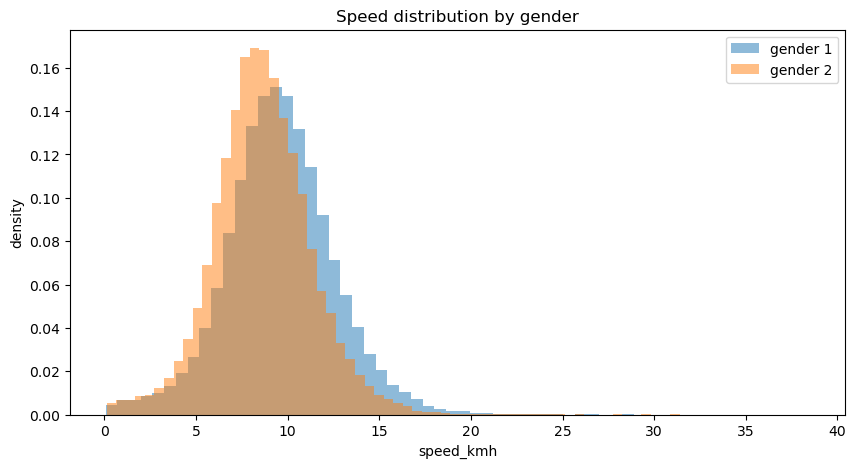

In [27]:
import matplotlib.pyplot as plt

df = speed_sample.to_pandas()

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["gender"] == 1]["speed_kmh"],
    bins=60,
    alpha=0.5,
    label="gender 1",
    density=True
)

plt.hist(
    df[df["gender"] == 2]["speed_kmh"],
    bins=60,
    alpha=0.5,
    label="gender 2",
    density=True
)

plt.xlabel("speed_kmh")
plt.ylabel("density")
plt.title("Speed distribution by gender")
plt.legend()
plt.show()

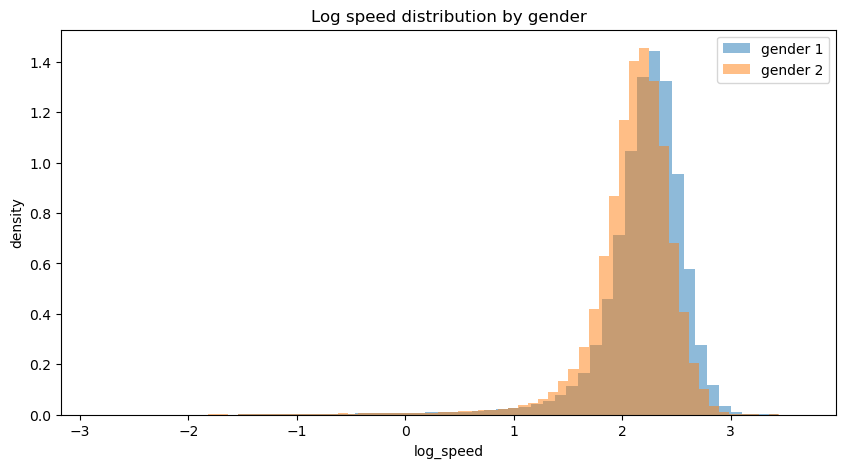

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["gender"] == 1]["log_speed"],
    bins=60,
    alpha=0.5,
    label="gender 1",
    density=True
)

plt.hist(
    df[df["gender"] == 2]["log_speed"],
    bins=60,
    alpha=0.5,
    label="gender 2",
    density=True
)

plt.xlabel("log_speed")
plt.ylabel("density")
plt.title("Log speed distribution by gender")
plt.legend()
plt.show()

In [29]:
#model

In [30]:
%%duckdb -t pl -o nb_train

SELECT
    gender,
    speed_kmh,
    ln(speed_kmh) AS log_speed
FROM get_gender_speed_data()
WHERE row_id % 5 != 0
  AND row_id % 20 = 1;

gender,speed_kmh,log_speed
i64,f64,f64
2,9.432573,2.244169
1,12.172145,2.49915
1,12.085509,2.492007
2,5.515737,1.707605
1,7.21429,1.976064
…,…,…
1,8.626911,2.154887
1,11.650291,2.455331
1,13.772565,2.622679


In [31]:
%%duckdb -t pl -o nb_test

SELECT
    gender,
    speed_kmh,
    ln(speed_kmh) AS log_speed
FROM get_gender_speed_data()
WHERE row_id % 5 = 0
  AND row_id % 50 = 0;

gender,speed_kmh,log_speed
i64,f64,f64
1,10.344465,2.336452
1,8.618109,2.153866
1,6.730873,1.906705
1,7.526244,2.018396
1,7.012769,1.947733
…,…,…
2,4.470557,1.497513
1,0.278621,-1.277904
1,7.773645,2.050739


In [32]:
print(nb_train.shape)
print(nb_test.shape)

(1025238, 3)
(410094, 3)


In [33]:
import numpy as np
import pandas as pd
import polars as pl

train = nb_train.to_pandas()
test = nb_test.to_pandas()

classes = sorted(train["gender"].unique())

params = {}

for c in classes:
    values = train[train["gender"] == c]["log_speed"].to_numpy()

    params[c] = {
        "prior": len(values) / len(train),
        "mean": values.mean(),
        "std": values.std()
    }

params

{np.int64(1): {'prior': 0.761319810619583,
  'mean': np.float64(2.194822048636557),
  'std': np.float64(0.4047675660145525)},
 np.int64(2): {'prior': 0.23868018938041705,
  'mean': np.float64(2.0874605632464753),
  'std': np.float64(0.4011977429100019)}}

In [34]:
def normal_log_density(x, mean, std):
    return (
        -np.log(std)
        -0.5 * np.log(2 * np.pi)
        -0.5 * ((x - mean) / std) ** 2
    )


def predict_one(x):
    scores = {}

    for c in classes:
        prior = params[c]["prior"]
        mean = params[c]["mean"]
        std = params[c]["std"]

        scores[c] = np.log(prior) + normal_log_density(x, mean, std)

    return max(scores, key=scores.get)


X_test = test["log_speed"].to_numpy()
y_test = test["gender"].to_numpy()

y_pred = np.array([predict_one(x) for x in X_test])


accuracy = np.mean(y_pred == y_test)

print("NB accuracy:", accuracy)


most_common_gender = train["gender"].value_counts().idxmax()
baseline_pred = np.repeat(most_common_gender, len(test))

baseline_accuracy = np.mean(baseline_pred == y_test)

print("Baseline accuracy:", baseline_accuracy)
print("NB accuracy:", accuracy)



NB accuracy: 0.7584651323842826
Baseline accuracy: 0.7609889439982053
NB accuracy: 0.7584651323842826


In [38]:
cm = pd.crosstab(
    pd.Series(y_test, name="actual"),
    pd.Series(y_pred, name="predicted")
)

cm

predicted,1,2
actual,,
1,310522,1555
2,97497,520


In [40]:
cm_rate = cm.div(cm.sum(axis=1), axis=0)
cm_rate

predicted,1,2
actual,,
1,0.995017,0.004983
2,0.994695,0.005305
